# Supervised Model

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import pandas as pd
import matplotlib.pyplot as plt

In [6]:
active_pairs = pd.read_csv("../data/manipulated/active_pairs.csv")

train_residuals = pd.read_csv("../data/manipulated/residuals_train.csv", index_col=0, parse_dates=True)
val_residuals = pd.read_csv("../data/manipulated/residuals_val.csv", index_col=0, parse_dates=True)
test_residuals = pd.read_csv("../data/manipulated/residuals_test.csv", index_col=0, parse_dates=True)

train_start = train_residuals.index.min()
train_end = train_residuals.index.max()

val_start = val_residuals.index.min()
val_end = val_residuals.index.max()

test_start = test_residuals.index.min()
test_end = test_residuals.index.max()

In [7]:
FEATURES = ["spread", "z_score", "regime"]
TARGET = "final_signal"

In [8]:
train_frames = []
val_frames = []
test_frames  = []

for _, row in active_pairs.iterrows():
    a, b, beta = row['asset_a'], row['asset_b'], row['beta']

    path = f'../data/manipulated/spreads/{a}_{b}.csv'
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    
    df = df[FEATURES + [TARGET]].dropna()
    train_frames.append(df.loc[train_start:train_end])
    val_frames.append(df.loc[val_start:val_end])
    test_frames.append(df.loc[test_start:test_end])

train_df = pd.concat(train_frames)
val_df = pd.concat(val_frames)
test_df  = pd.concat(test_frames)

print(f'Train rows: {len(train_df):,}  | Val rows: {len(val_df):,} | Test rows: {len(test_df):,}')
print('Train class distribution:')
print(train_df[TARGET].value_counts().sort_index())

Train rows: 214,890  | Val rows: 28,728 | Test rows: 28,500
Train class distribution:
final_signal
-1      8162
 0    197039
 1      9689
Name: count, dtype: int64


<BarContainer object of 3 artists>

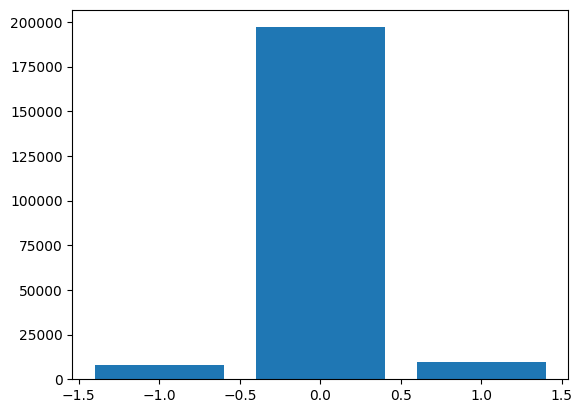

In [9]:
plt.bar([-1, 0, 1], train_df[TARGET].value_counts().sort_index())

In [10]:
X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values
X_val = val_df[FEATURES].values
y_val = val_df[TARGET].values
X_test  = test_df[FEATURES].values
y_test  = test_df[TARGET].values

# Scale features (spread is raw price, z_score is normalised, regime is 0..k-1 - all different scales)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit only on train
X_val = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [11]:
model = LogisticRegression(
    solver='lbfgs',
    class_weight='balanced',   # handles 0-heavy imbalance
    max_iter=1000,
    random_state=42,
)
model.fit(X_train, y_train)
print('Classes:', model.classes_)

Classes: [-1  0  1]


In [12]:
# --- Training performance ---
y_train_pred = model.predict(X_train)
print('=== Train ===')
print(classification_report(y_train, y_train_pred, target_names=['Short (-1)', 'Exit (0)', 'Long (1)']))

=== Train ===
              precision    recall  f1-score   support

  Short (-1)       0.23      1.00      0.37      8162
    Exit (0)       1.00      0.73      0.85    197039
    Long (1)       0.28      1.00      0.44      9689

    accuracy                           0.75    214890
   macro avg       0.50      0.91      0.55    214890
weighted avg       0.94      0.75      0.81    214890



In [13]:
# --- Val performance ---
y_val_pred = model.predict(X_val)
print('=== Validation ===')
print(classification_report(y_val, y_val_pred, target_names=['Short (-1)', 'Exit (0)', 'Long (1)']))

=== Validation ===
              precision    recall  f1-score   support

  Short (-1)       0.15      1.00      0.27       675
    Exit (0)       1.00      0.74      0.85     27337
    Long (1)       0.17      1.00      0.29       716

    accuracy                           0.75     28728
   macro avg       0.44      0.91      0.47     28728
weighted avg       0.96      0.75      0.82     28728



In [14]:
coef_df = pd.DataFrame(model.coef_, index=[f"Class {c}" for c in model.classes_], columns=FEATURES)
print(coef_df.round(4))

          spread  z_score  regime
Class -1 -0.1011   3.9258 -0.0981
Class 0   0.0676  -0.0083  0.0325
Class 1   0.0335  -3.9176  0.0655


In [15]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)
model.fit(X_train, y_train)
print('Classes:', model.classes_)

Classes: [-1  0  1]


In [16]:
# --- Training performance ---
y_train_pred = model.predict(X_train)
print('=== Train ===')
print(classification_report(y_train, y_train_pred, target_names=['Short (-1)', 'Exit (0)', 'Long (1)']))

=== Train ===
              precision    recall  f1-score   support

  Short (-1)       0.00      0.00      0.00      8162
    Exit (0)       0.93      0.99      0.96    197039
    Long (1)       0.69      0.40      0.50      9689

    accuracy                           0.93    214890
   macro avg       0.54      0.46      0.49    214890
weighted avg       0.89      0.93      0.90    214890



/home/dilab/Documents/CSCI4022/pairs-trading-ml/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dilab/Documents/CSCI4022/pairs-trading-ml/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dilab/Documents/CSCI4022/pairs-trading-ml/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

In [17]:
# --- Val performance ---
y_val_pred = model.predict(X_val)
print('=== Validation ===')
print(classification_report(y_val, y_val_pred, target_names=['Short (-1)', 'Exit (0)', 'Long (1)']))

=== Validation ===
              precision    recall  f1-score   support

  Short (-1)       0.00      0.00      0.00       675
    Exit (0)       0.96      0.98      0.97     27337
    Long (1)       0.41      0.43      0.42       716

    accuracy                           0.95     28728
   macro avg       0.46      0.47      0.46     28728
weighted avg       0.92      0.95      0.94     28728



/home/dilab/Documents/CSCI4022/pairs-trading-ml/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dilab/Documents/CSCI4022/pairs-trading-ml/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dilab/Documents/CSCI4022/pairs-trading-ml/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

In [18]:
importances = pd.Series(model.feature_importances_, index=FEATURES)
print(importances.sort_values())

regime     0.023220
spread     0.333663
z_score    0.643118
dtype: float64


In [19]:
# Write model_signal back to each spread CSV for use in backtest
for _, row in active_pairs.iterrows():
    a, b = row["asset_a"], row["asset_b"]
    path = f"../data/manipulated/spreads/{a}_{b}.csv"
    df = pd.read_csv(path, index_col=0, parse_dates=True)

    valid = df[FEATURES].dropna()
    X = scaler.transform(valid.values)
    df.loc[valid.index, "model_signal"] = model.predict(X)
    df.to_csv(path)

print(f"model_signal written to {len(active_pairs)} spread files")

model_signal written to 114 spread files
